# Amazon Sales Report — Keşifsel Veri Analizi (EDA)

**Amaç:** `Amazon Sale Report.csv` dosyasındaki ~129 bin satış kaydını analiz ederek:
1. Veri kalitesini değerlendirmek
2. Her sütunun düşürülme/tutulma kararını **görsellerle** ispatlamak
3. Eksik verilerin doldurma stratejisini belirlemek
4. Son olarak temizlenmiş veriyi ayrı bir dosyaya kaydetmek

> ⚠️ Orijinal CSV dosyası **hiçbir şekilde** değiştirilmeyecektir.

---
## 1. Kurulum & Import

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import missingno as msno
import warnings

warnings.filterwarnings('ignore')
sns.set_theme(style='whitegrid', palette='muted', font_scale=1.1)
plt.rcParams['figure.figsize'] = (14, 6)
plt.rcParams['figure.dpi'] = 100

CSV_PATH = '../database/Amazon Sale Report.csv'


---
## 2. Veri Yükleme & İlk Bakış

In [2]:
df_raw = pd.read_csv(CSV_PATH)
print(f'Veri boyutu: {df_raw.shape[0]:,} satır × {df_raw.shape[1]} sütun')
df_raw.head(3)

Veri boyutu: 128,975 satır × 24 sütun


,index,Order ID,Date,Status,Fulfilment,Sales Channel,ship-service-level,Style,SKU,Category,...,currency,Amount,ship-city,ship-state,ship-postal-code,ship-country,promotion-ids,B2B,fulfilled-by,Unnamed: 22
0,0,405-8078784-5731545,04-30-22,Cancelled,Merchant,Amazon.in,Standard,SET389,SET389-KR-NP-S,Set,...,INR,647.62,MUMBAI,MAHARASHTRA,400081.0,IN,NaN,False,Easy Ship,NaN
1,1,171-9198151-1101146,04-30-22,Shipped - Delivered to Buyer,Merchant,Amazon.in,Standard,JNE3781,JNE3781-KR-XXXL,kurta,...,INR,406.00,BENGALURU,KARNATAKA,560085.0,IN,Amazon PLCC Free-Financing Universal Merchant ...,False,Easy Ship,NaN
2,2,404-0687676-7273146,04-30-22,Shipped,Amazon,Amazon.in,Expedited,JNE3371,JNE3371-KR-XL,kurta,...,INR,329.00,NAVI MUMBAI,MAHARASHTRA,410210.0,IN,IN Core Free Shipping 2015/04/08 23-48-5-108,True,NaN,NaN


In [3]:
df_raw.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 128975 entries, 0 to 128974
Data columns (total 24 columns):
 #   Column              Non-Null Count   Dtype  
---  ------              --------------   -----  
 0   index               128975 non-null  int64  
 1   Order ID            128975 non-null  object 
 2   Date                128975 non-null  object 
 3   Status              128975 non-null  object 
 4   Fulfilment          128975 non-null  object 
 5   Sales Channel       128975 non-null  object 
 6   ship-service-level  128975 non-null  object 
 7   Style               128975 non-null  object 
 8   SKU                 128975 non-null  object 
 9   Category            128975 non-null  object 
 10  Size                128975 non-null  object 
 11  ASIN                128975 non-null  object 
 12  Courier Status      122103 non-null  object 
 13  Qty                 128975 non-null  int64  
 14  currency            121180 non-null  object 
 15  Amount              121180 non-nul

In [4]:
df_raw.describe(include='all').T

,count,unique,top,freq,mean,std,min,25%,50%,75%,max
index,128975.0,NaN,NaN,NaN,64487.0,37232.019822,0.0,32243.5,64487.0,96730.5,128974.0
Order ID,128975,120378,171-5057375-2831560,12,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Date,128975,91,05-03-22,2085,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Status,128975,13,Shipped,77804,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Fulfilment,128975,2,Amazon,89698,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Sales Channel,128975,2,Amazon.in,128851,NaN,NaN,NaN,NaN,NaN,NaN,NaN
ship-service-level,128975,2,Expedited,88615,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Style,128975,1377,JNE3797,4224,NaN,NaN,NaN,NaN,NaN,NaN,NaN
SKU,128975,7195,JNE3797-KR-L,773,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Category,128975,9,Set,50284,NaN,NaN,NaN,NaN,NaN,NaN,NaN


---
## 3. Eksik Veri Analizi

Önce her sütundaki boşluk oranını sayısal olarak görelim, ardından `missingno` ile görselleştirelim.

In [5]:
# Eksik veri tablosu
missing = df_raw.isnull().sum()
missing_pct = (missing / len(df_raw) * 100).round(2)
missing_df = pd.DataFrame({
    'Eksik Sayı': missing,
    'Eksik %': missing_pct
}).sort_values('Eksik %', ascending=False)

missing_df[missing_df['Eksik Sayı'] > 0]

,Eksik Sayı,Eksik %
fulfilled-by,89698,69.55
promotion-ids,49153,38.11
Unnamed: 22,49050,38.03
currency,7795,6.04
Amount,7795,6.04
Courier Status,6872,5.33
ship-country,33,0.03
ship-postal-code,33,0.03
ship-state,33,0.03
ship-city,33,0.03


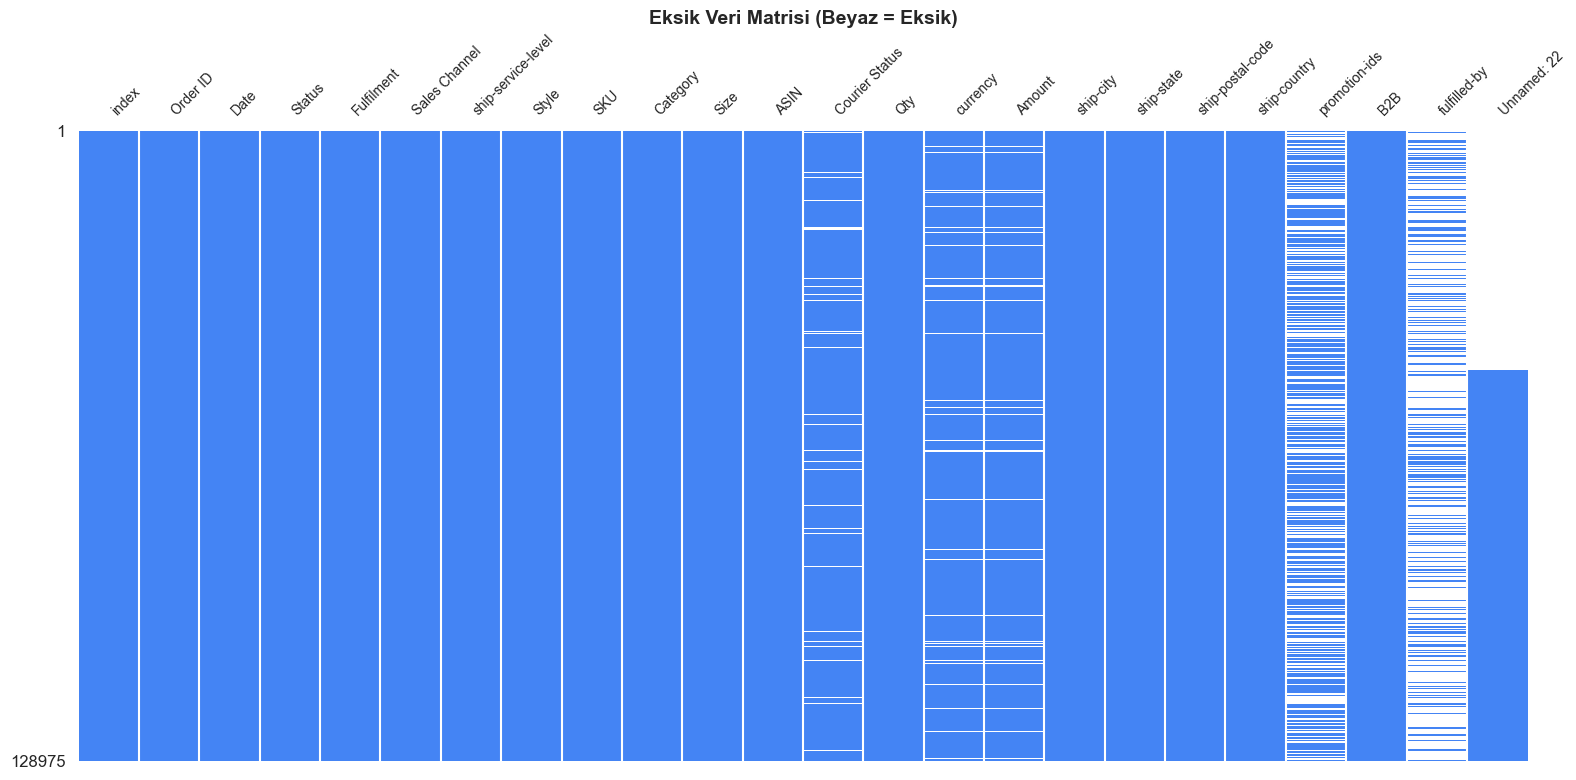

In [6]:
# missingno matrix — tüm veri üzerinde eksiklik deseni
fig, ax = plt.subplots(figsize=(16, 8))
msno.matrix(df_raw, ax=ax, sparkline=False, fontsize=10, color=(0.27, 0.52, 0.96))
ax.set_title('Eksik Veri Matrisi (Beyaz = Eksik)', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

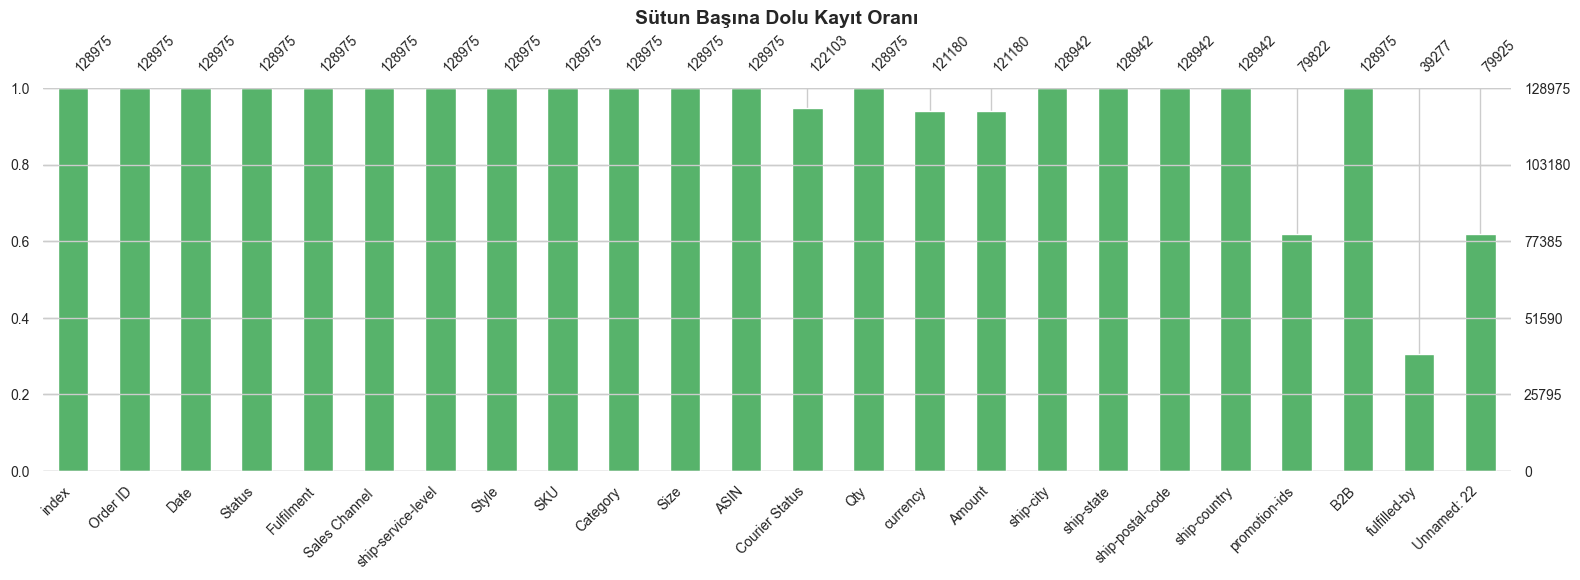

In [7]:
# missingno bar chart — dolu kayıt oranları
fig, ax = plt.subplots(figsize=(16, 6))
msno.bar(df_raw, ax=ax, fontsize=10, color=(0.34, 0.70, 0.42))
ax.set_title('Sütun Başına Dolu Kayıt Oranı', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

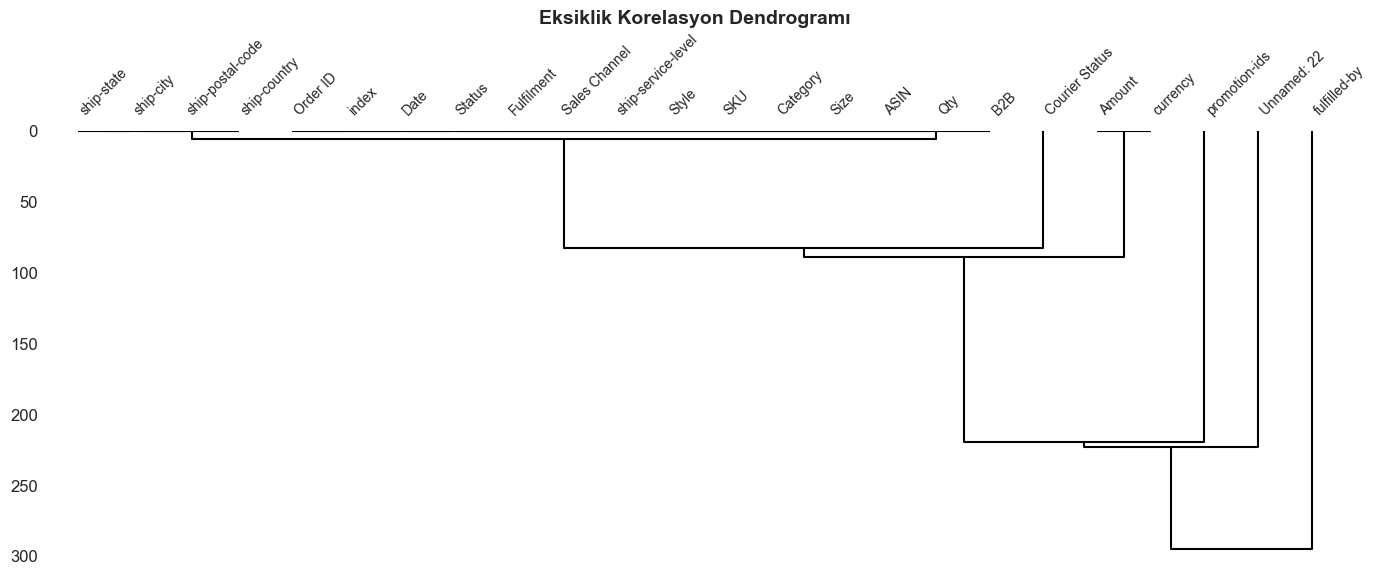

In [8]:
# missingno dendrogram — eksiklik korelasyonu
fig, ax = plt.subplots(figsize=(14, 6))
msno.dendrogram(df_raw, ax=ax, fontsize=10)
ax.set_title('Eksiklik Korelasyon Dendrogramı', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

### 3.1 Gözlem

Dendrogramdan ve matris grafiklerinden:
- `currency` ve `Amount` eksiklikleri **birebir örtüşüyor** → aynı satırlar
- `fulfilled-by` neredeyse **%70 boş** — kullanılamaz
- `Unnamed: 22` ve `promotion-ids` birlikte yüksek eksiklik → muhtemelen opsiyonel alanlar
- `ship-city/state/postal/country` çok az eksik (33 satır) → kolayca doldurulabilir
- `Courier Status` eksiklikleri genellikle `Cancelled` siparişlerle örtüşüyor olabilir

---
## 4. Sütun Sütun Analiz & Düşürme Kararları

Her sütunu tek tek inceleyerek **tutma, düşürme veya dönüştürme** kararını ispatlayacağız.

### 4.1 `index` Sütunu

In [9]:
# index sütunu sadece satır numarası — pandas zaten kendi indeksini tutuyor
print(f"index sütunu min: {df_raw['index'].min()}, max: {df_raw['index'].max()}")
print(f"Unique count: {df_raw['index'].nunique()} vs satır sayısı: {len(df_raw)}")
print('       Bu sütun sıralı integer, bilgi taşımıyor.')

index sütunu min: 0, max: 128974
Unique count: 128975 vs satır sayısı: 128975
       Bu sütun sıralı integer, bilgi taşımıyor.


> **Gerekçe:** Pandas DataFrame kendi indeksini otomatik oluşturur.

> **Analiz Kararı:** DÜŞÜR

### 4.2 `Unnamed: 22` Sütunu

In [10]:
print(f"Boş olmayan kayıt sayısı: {df_raw['Unnamed: 22'].notna().sum()}")
print(f"Toplam kayıt: {len(df_raw)}")
print(f"Boş oranı: {df_raw['Unnamed: 22'].isna().mean() * 100:.1f}%")
# Boş olmayan değerlere bakalım
non_null_vals = df_raw['Unnamed: 22'].dropna().unique()
print(f"Boş olmayan unique değerler ({len(non_null_vals)} adet): {non_null_vals[:10]}")


Boş olmayan kayıt sayısı: 79925
Toplam kayıt: 128975
Boş oranı: 38.0%
Boş olmayan unique değerler (1 adet): [False]


> **Gerekçe:** %38 boş, kalan değerler de anlamsız.
CSV dışa aktarımından kalan artık (orphan) sütun.

> **Analiz Kararı:** DÜŞÜR

### 4.3 `currency` Sütunu

In [11]:
print('Unique değerler:', df_raw['currency'].dropna().unique())
print(f"Doluluk: {df_raw['currency'].notna().sum():,} / {len(df_raw):,}")


Unique değerler: ['INR']
Doluluk: 121,180 / 128,975


> **Gerekçe:** Tüm kayıtlar "INR" (Hint Rupisi).
Sıfır varyans → model için bilgi değeri yok.
Eksik olanlar da Amount eksik olan satırlarla birebir.

> **Analiz Kararı:** DÜŞÜR

### 4.4 `promotion-ids` Sütunu

In [12]:
print(f"Eksik: {df_raw['promotion-ids'].isna().sum():,} ({df_raw['promotion-ids'].isna().mean()*100:.1f}%)")
# Dolu olanlardan örnek
sample_promos = df_raw['promotion-ids'].dropna().iloc[0]
print(f"Örnek değer (karakter sayısı: {len(sample_promos)}):")
print(sample_promos[:200], '...')
print(f"Unique promosyon sayısı: {df_raw['promotion-ids'].nunique():,}")
print('       Parsing maliyeti yüksek, karmaşık string → feature olarak kullanılamaz.')

Eksik: 49,153 (38.1%)
Örnek değer (karakter sayısı: 1606):
Amazon PLCC Free-Financing Universal Merchant AAT-WNKTBO3K27EJC,Amazon PLCC Free-Financing Universal Merchant AAT-QX3UCCJESKPA2,Amazon PLCC Free-Financing Universal Merchant AAT-5QQ7BIYYQEDN2,Amazon P ...
Unique promosyon sayısı: 5,787
       Parsing maliyeti yüksek, karmaşık string → feature olarak kullanılamaz.


> **Gerekçe:** %38 eksik, her kayıtta farklı uzun string.
Talep tahmini için ilgisiz — promosyon etkisi ayrı bir çalışma.

> **Analiz Kararı:** DÜŞÜR

### 4.5 `fulfilled-by` Sütunu

In [13]:
print(f"Eksik: {df_raw['fulfilled-by'].isna().sum():,} ({df_raw['fulfilled-by'].isna().mean()*100:.1f}%)")
print(df_raw['fulfilled-by'].value_counts())

# Bu sütun Fulfilment ile ne kadar örtüşüyor?
print(df_raw['Fulfilment'].value_counts())


Eksik: 89,698 (69.5%)
fulfilled-by
Easy Ship    39277
Name: count, dtype: int64
Fulfilment
Amazon      89698
Merchant    39277
Name: count, dtype: int64


Dolu olan değerler:

Fulfilment sütunu dağılımı:

> **Gerekçe:** %69.6 eksik — veri imputation güvenilir olmaz.
"Easy Ship" bilgisi zaten Fulfilment sütunuyla örtüşüyor.

> **Analiz Kararı:** DÜŞÜR

### 4.6 `Sales Channel` Sütunu

In [14]:
print(df_raw['Sales Channel '].value_counts())


Sales Channel 
Amazon.in     128851
Non-Amazon       124
Name: count, dtype: int64


Unique değerler:

> **Gerekçe:** Tamamı "Amazon.in" — sıfır varyans.
Tek kanallı veri → bu sütun bilgi taşımıyor.

> **Analiz Kararı:** DÜŞÜR

### 4.7 `Courier Status` vs `Status` — Redundancy Kontrolü

In [15]:
# İki sütunun crosstab'ı
ct = pd.crosstab(df_raw['Status'], df_raw['Courier Status'].fillna('(Boş)'), margins=True)
ct.head(15)

Courier Status,(Boş),Cancelled,Shipped,Unshipped,All
Status,,,,,
Cancelled,6861,5840,0,5631,18332
Pending,0,2,10,646,658
Pending - Waiting for Pick Up,0,0,0,281,281
Shipped,0,93,77596,115,77804
Shipped - Damaged,0,0,1,0,1
Shipped - Delivered to Buyer,8,0,28761,0,28769
Shipped - Lost in Transit,0,0,5,0,5
Shipped - Out for Delivery,0,0,35,0,35
Shipped - Picked Up,0,0,973,0,973


Status × Courier Status Çapraz Tablosu (ilk 10 Status):

In [16]:
# Courier Status boş olanların Status dağılımı
courier_null_mask = df_raw['Courier Status'].isna()
print(df_raw.loc[courier_null_mask, 'Status'].value_counts())
print('       Courier Status, Status\'un alt kümesi — redundant.')

Status
Cancelled                       6861
Shipped - Delivered to Buyer       8
Shipped - Returned to Seller       3
Name: count, dtype: int64
       Courier Status, Status'un alt kümesi — redundant.


Courier Status BOŞ olan satırların Status dağılımı:

> **Gerekçe:** Courier Status eksik olan kayıtların büyük çoğunluğu "Cancelled" → doğal.
Status sütunu daha zengin bilgi taşıyor ve hiç eksik yok.

> **Analiz Kararı:** DÜŞÜR

### 4.8 `ASIN` Sütunu

In [17]:
print(f"Unique ASIN sayısı: {df_raw['ASIN'].nunique()}")
print(f"Unique SKU sayısı: {df_raw['SKU'].nunique()}")
# ASIN ile SKU arasında 1:1 mapping var mı?
asin_per_sku = df_raw.groupby('SKU')['ASIN'].nunique()
print(f"SKU başına ortalama ASIN: {asin_per_sku.mean():.2f}")
print(f"1'den fazla ASIN'e sahip SKU sayısı: {(asin_per_sku > 1).sum()}")


Unique ASIN sayısı: 7190
Unique SKU sayısı: 7195
SKU başına ortalama ASIN: 1.00
1'den fazla ASIN'e sahip SKU sayısı: 5


> **Gerekçe:** Amazon iç tanımlayıcısı, tahmin modeli için bilgi değeri yok.
SKU zaten ürün tanımlayıcısı olarak yeterli.

> **Analiz Kararı:** DÜŞÜR

### 4.9 `ship-service-level` Sütunu

In [18]:
print(df_raw['ship-service-level'].value_counts())
print('       Kargo hızı, talep tahmini modelinin kapsamı dışında.')

ship-service-level
Expedited    88615
Standard     40360
Name: count, dtype: int64
       Kargo hızı, talep tahmini modelinin kapsamı dışında.


Değer dağılımı:

> **Gerekçe:** Çoğunluk "Standard" ve "Expedited" — envanter risk tahmini için ilgisiz.

> **Analiz Kararı:** DÜŞÜR

### 4.10 Tutulacak Sütunlar

| Sütun | Neden Tutuyoruz |
|---|---|
| `Order ID` | İşlem kimliği — aggregation ve doğrulama için |
| `Date` | Zaman serisi analizi için kritik |
| `Status` | Gerçek satışları filtrelemek için |
| `Fulfilment` | Amazon vs Merchant ayrımı — iş zekası |
| `Style` | Ürün stili — ek feature |
| `SKU` | Ürün tanımlayıcısı — temel analiz birimi |
| `Category` | Ürün kategorisi — aggregation ve feature |
| `Size` | Ürün boyutu — isteğe bağlı feature |
| `Qty` | Satış miktarı — hedef değişken |
| `Amount` | Satış tutarı (INR) — ek feature |
| `ship-city` | Coğrafi analiz |
| `ship-state` | Coğrafi analiz |
| `ship-postal-code` | Coğrafi analiz (opsiyonel) |
| `ship-country` | Doğrulama (tümü IN olmalı) |
| `B2B` | İşletmeler arası satış flag'i |

---
## 5. Sipariş Durumu (Status) Analizi

Talep tahmini için hangi siparişleri "gerçek satış" sayacağımızı belirlemeliyiz.

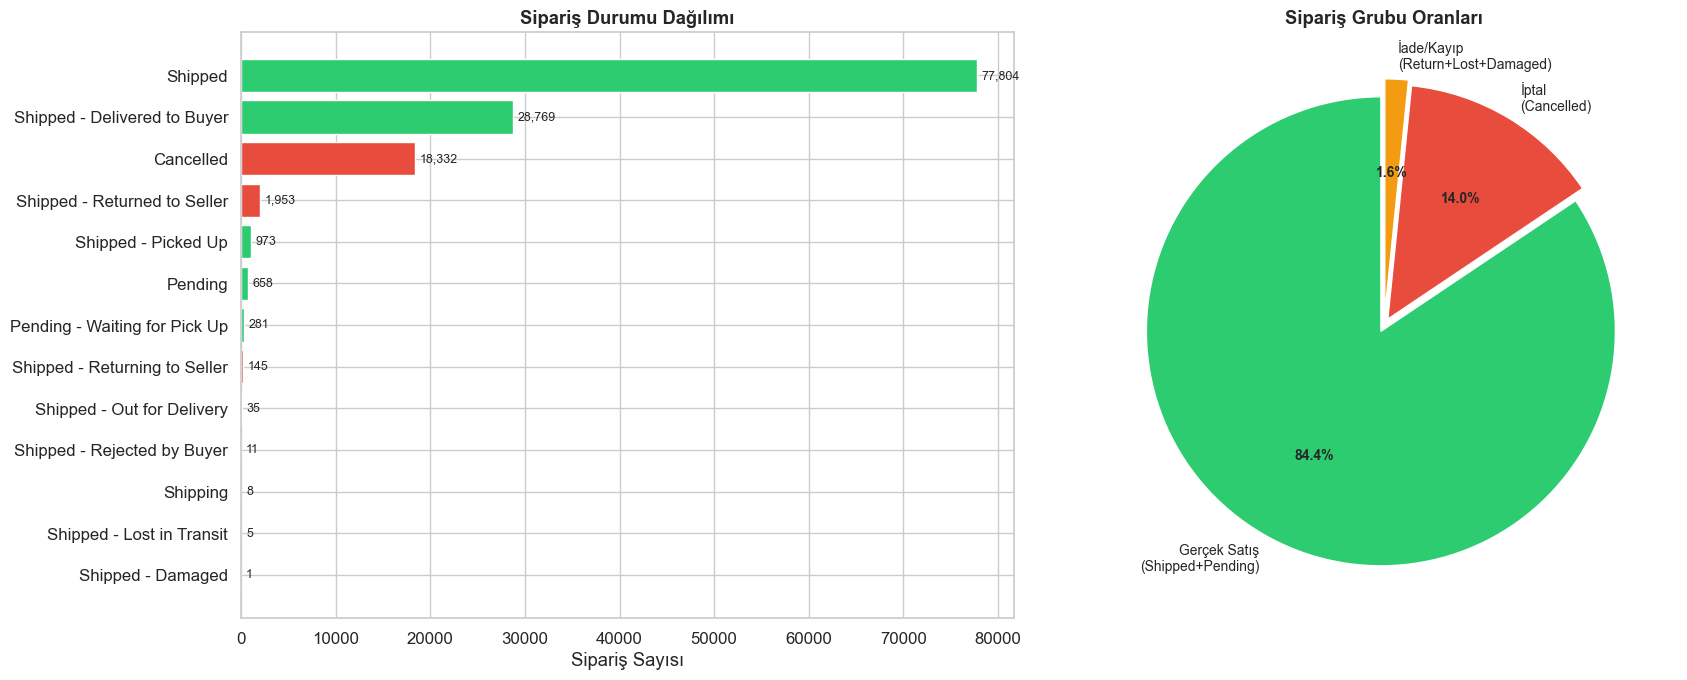


📊 Gerçek satış: 110,643 (85.8%)
❌ İptal: 18,332 (14.2%)
↩️  İade/Kayıp/Hasar: 2,115 (1.6%)


In [19]:
status_counts = df_raw['Status'].value_counts()

fig, axes = plt.subplots(1, 2, figsize=(18, 7))

# Bar chart
colors = ['#2ecc71' if s in ['Shipped', 'Shipped - Delivered to Buyer', 
                              'Shipped - Out for Delivery', 'Shipped - Picked Up',
                              'Pending', 'Pending - Waiting for Pick Up', 'Shipping']
          else '#e74c3c' for s in status_counts.index]

bars = axes[0].barh(status_counts.index[::-1], status_counts.values[::-1], color=colors[::-1])
axes[0].set_xlabel('Sipariş Sayısı')
axes[0].set_title('Sipariş Durumu Dağılımı', fontweight='bold')

# Her barın yanına sayı
for bar, val in zip(bars, status_counts.values[::-1]):
    axes[0].text(bar.get_width() + 500, bar.get_y() + bar.get_height()/2, 
                f'{val:,}', va='center', fontsize=9)

# Pie chart — basitleştirilmiş gruplar
shipped_total = df_raw['Status'].str.startswith('Shipped').sum() + \
                df_raw['Status'].str.startswith('Pending').sum() + \
                df_raw['Status'].str.startswith('Shipping').sum()
cancelled_total = (df_raw['Status'] == 'Cancelled').sum()
returned_total = df_raw['Status'].str.contains('Return|Reject|Damaged|Lost', na=False).sum()

labels = ['Gerçek Satış\n(Shipped+Pending)', 'İptal\n(Cancelled)', 'İade/Kayıp\n(Return+Lost+Damaged)']
sizes = [shipped_total, cancelled_total, returned_total]
pie_colors = ['#2ecc71', '#e74c3c', '#f39c12']
explode = (0.03, 0.03, 0.05)

wedges, texts, autotexts = axes[1].pie(
    sizes, labels=labels, colors=pie_colors, autopct='%1.1f%%',
    startangle=90, explode=explode, textprops={'fontsize': 10}
)
for autotext in autotexts:
    autotext.set_fontweight('bold')
axes[1].set_title('Sipariş Grubu Oranları', fontweight='bold')

plt.tight_layout()
plt.show()

print(f'\n📊 Gerçek satış: {shipped_total:,} ({shipped_total/len(df_raw)*100:.1f}%)')
print(f'❌ İptal: {cancelled_total:,} ({cancelled_total/len(df_raw)*100:.1f}%)')
print(f'↩️  İade/Kayıp/Hasar: {returned_total:,} ({returned_total/len(df_raw)*100:.1f}%)')

### 5.1 Status Filtreleme Kararı

**Dahil edilecek (Yeşil):**
- `Shipped`, `Shipped - Delivered to Buyer`, `Shipped - Out for Delivery`, `Shipped - Picked Up`
- `Pending`, `Pending - Waiting for Pick Up`, `Shipping`

**Hariç tutulacak (Kırmızı/Turuncu):**
- `Cancelled` — tamamlanmamış sipariş, gerçek talep değil
- `Shipped - Returned to Seller` — müşteri iade etti
- `Shipped - Rejected by Buyer` — müşteri reddetti
- `Shipped - Lost in Transit` — kayıp
- `Shipped - Damaged` — hasarlı
- `Shipped - Returning to Seller` — iade sürecinde

**Gerekçe:** Talep tahmin modeli "gerçekleşen talebi" öğrenmeli. İptal ve iadeler **gerçek talep sinyali değil**.

---
## 6. Kategori Analizi

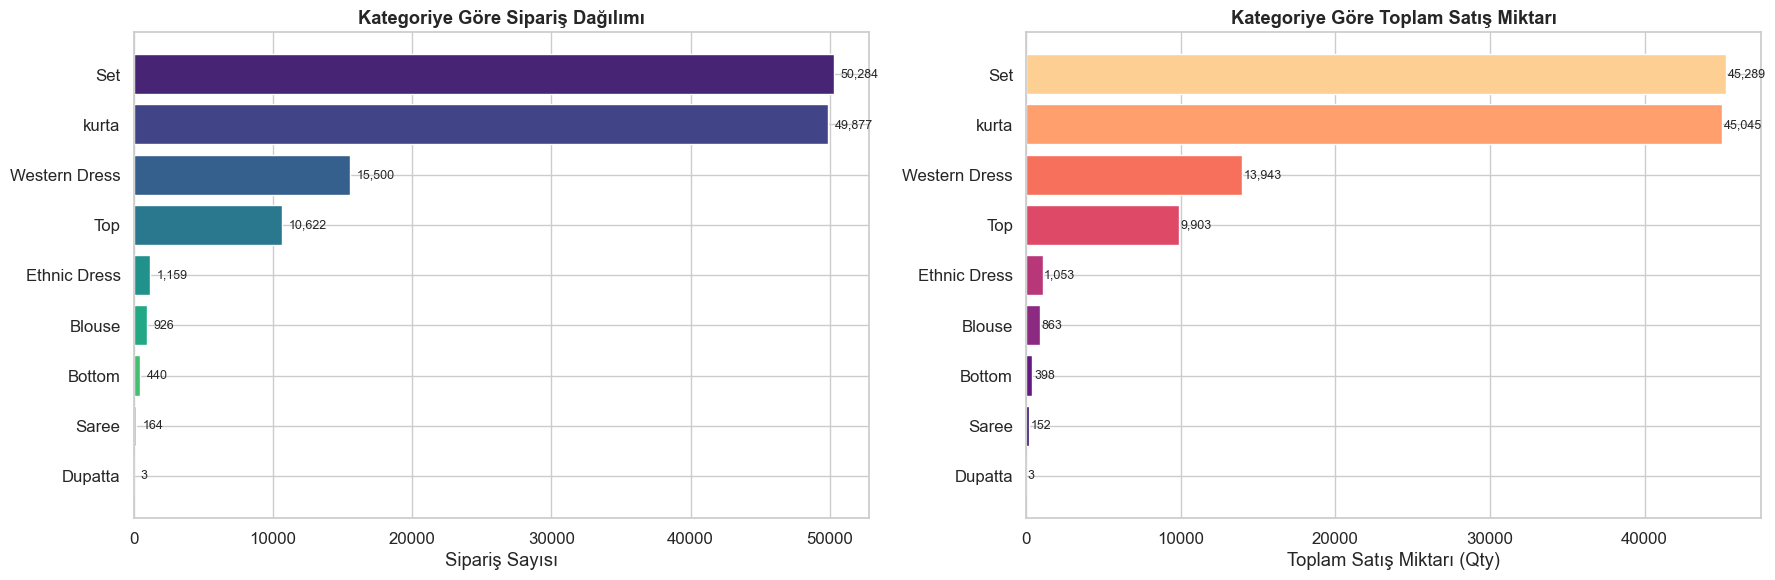

In [20]:
cat_counts = df_raw['Category'].value_counts()

fig, axes = plt.subplots(1, 2, figsize=(18, 6))

# Bar chart
palette = sns.color_palette('viridis', n_colors=len(cat_counts))
axes[0].barh(cat_counts.index[::-1], cat_counts.values[::-1], color=palette[::-1])
axes[0].set_xlabel('Sipariş Sayısı')
axes[0].set_title('Kategoriye Göre Sipariş Dağılımı', fontweight='bold')
for i, (val, cat) in enumerate(zip(cat_counts.values[::-1], cat_counts.index[::-1])):
    axes[0].text(val + 500, i, f'{val:,}', va='center', fontsize=9)

# Toplam miktar (Qty) bazlı
cat_qty = df_raw.groupby('Category')['Qty'].sum().sort_values(ascending=True)
axes[1].barh(cat_qty.index, cat_qty.values, color=sns.color_palette('magma', n_colors=len(cat_qty)))
axes[1].set_xlabel('Toplam Satış Miktarı (Qty)')
axes[1].set_title('Kategoriye Göre Toplam Satış Miktarı', fontweight='bold')
for i, val in enumerate(cat_qty.values):
    axes[1].text(val + 100, i, f'{val:,}', va='center', fontsize=9)

plt.tight_layout()
plt.show()

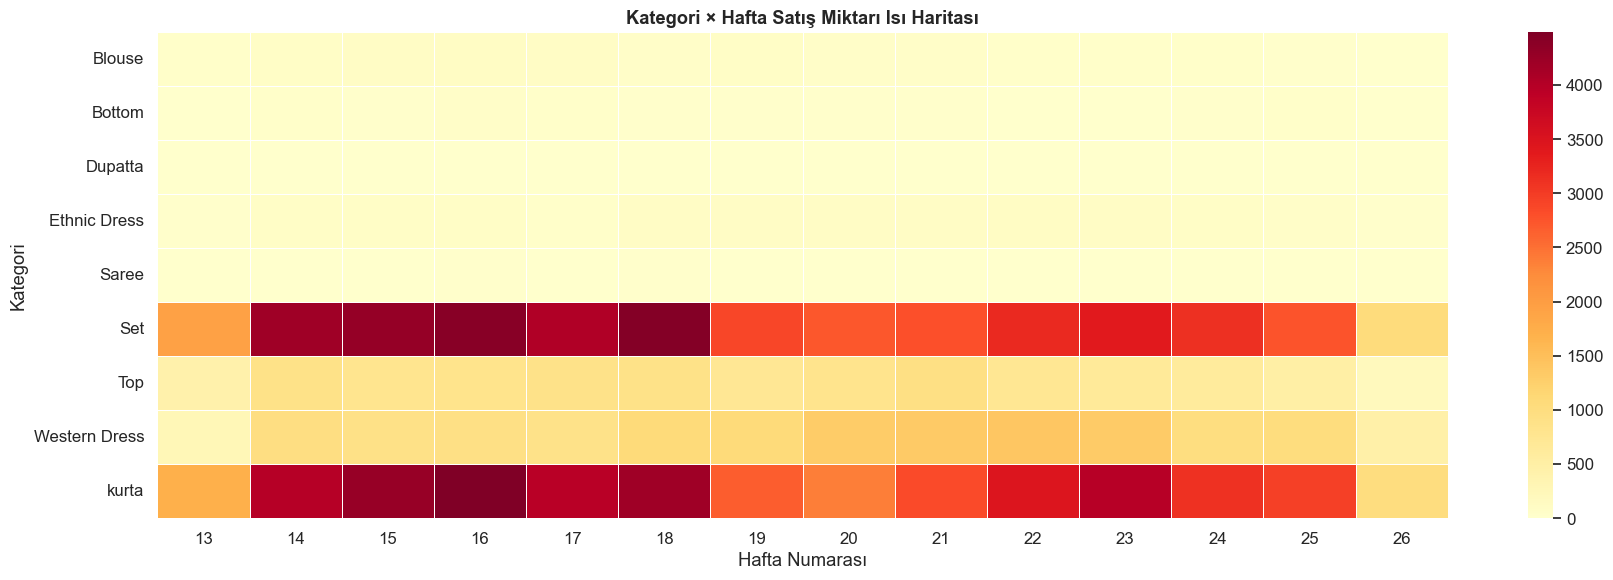

       Set ve kurta sürekli yüksek hacimli; Dupatta, Saree gibi niş kategoriler seyrek.


In [21]:
# Kategori × Gün heatmap (zaman trendi)
df_temp = df_raw.copy()
df_temp['Date'] = pd.to_datetime(df_temp['Date'], format='%m-%d-%y')
df_temp['Week'] = df_temp['Date'].dt.isocalendar().week.astype(int)

cat_week = df_temp.groupby(['Category', 'Week'])['Qty'].sum().unstack(fill_value=0)

fig, ax = plt.subplots(figsize=(18, 6))
sns.heatmap(cat_week, cmap='YlOrRd', annot=False, linewidths=0.5, ax=ax)
ax.set_title('Kategori × Hafta Satış Miktarı Isı Haritası', fontweight='bold')
ax.set_xlabel('Hafta Numarası')
ax.set_ylabel('Kategori')
plt.tight_layout()
plt.show()

print('       Set ve kurta sürekli yüksek hacimli; Dupatta, Saree gibi niş kategoriler seyrek.')

> **İş Zekası Yorumu:** Heatmap, kategoriler arasındaki mevsimsel farklılıkları gösteriyor.

---
## 7. Zaman Serisi Analizi

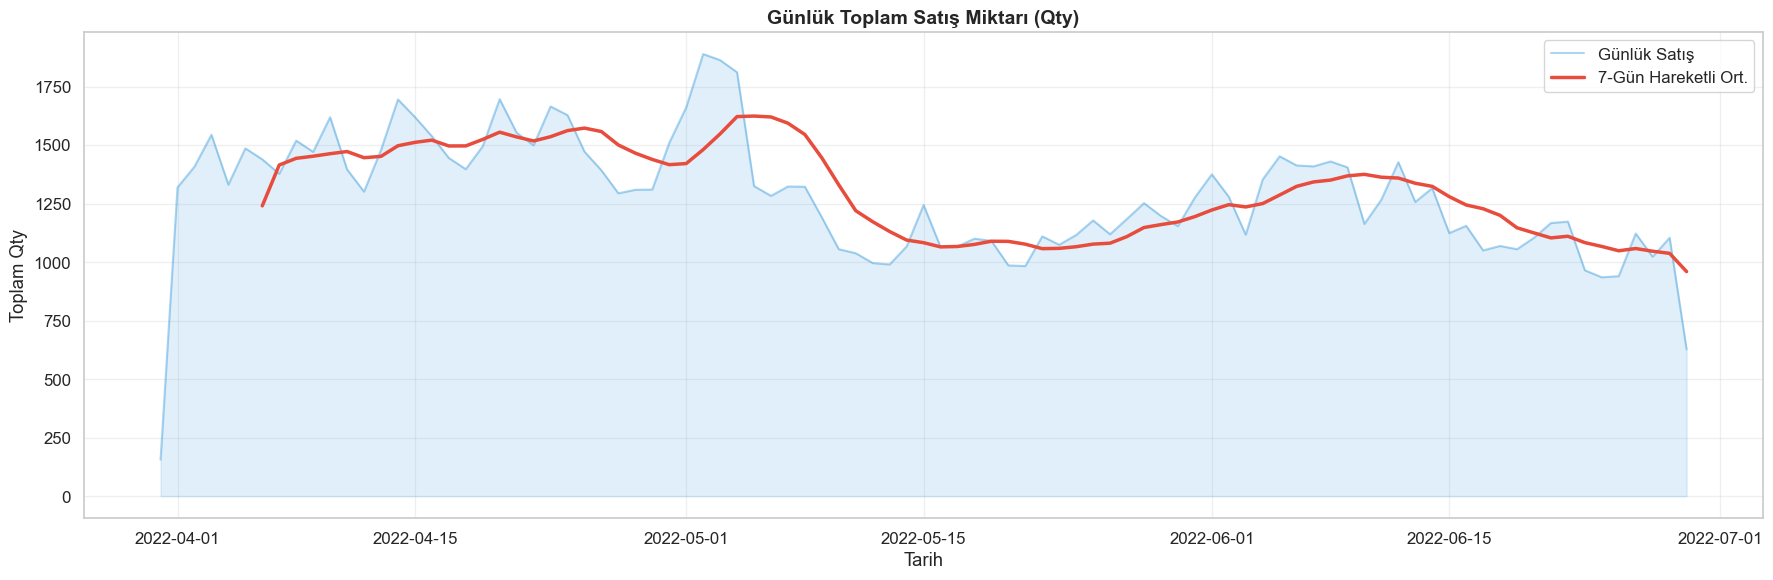

Tarih aralığı: 2022-03-31 → 2022-06-29
Toplam gün: 91
Günlük ort. satış: 1282, std: 260


In [22]:
# Tarih parse et
df_temp = df_raw.copy()
df_temp['Date'] = pd.to_datetime(df_temp['Date'], format='%m-%d-%y')

# Günlük toplam satış
daily_sales = df_temp.groupby('Date')['Qty'].sum().sort_index()
daily_sales_ma7 = daily_sales.rolling(7).mean()

fig, ax = plt.subplots(figsize=(18, 6))
ax.plot(daily_sales.index, daily_sales.values, alpha=0.4, color='#3498db', label='Günlük Satış')
ax.plot(daily_sales_ma7.index, daily_sales_ma7.values, color='#e74c3c', linewidth=2.5, label='7-Gün Hareketli Ort.')
ax.fill_between(daily_sales.index, daily_sales.values, alpha=0.15, color='#3498db')
ax.set_title('Günlük Toplam Satış Miktarı (Qty)', fontsize=14, fontweight='bold')
ax.set_xlabel('Tarih')
ax.set_ylabel('Toplam Qty')
ax.legend()
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

print(f'Tarih aralığı: {daily_sales.index.min().date()} → {daily_sales.index.max().date()}')
print(f'Toplam gün: {len(daily_sales)}')
print(f'Günlük ort. satış: {daily_sales.mean():.0f}, std: {daily_sales.std():.0f}')

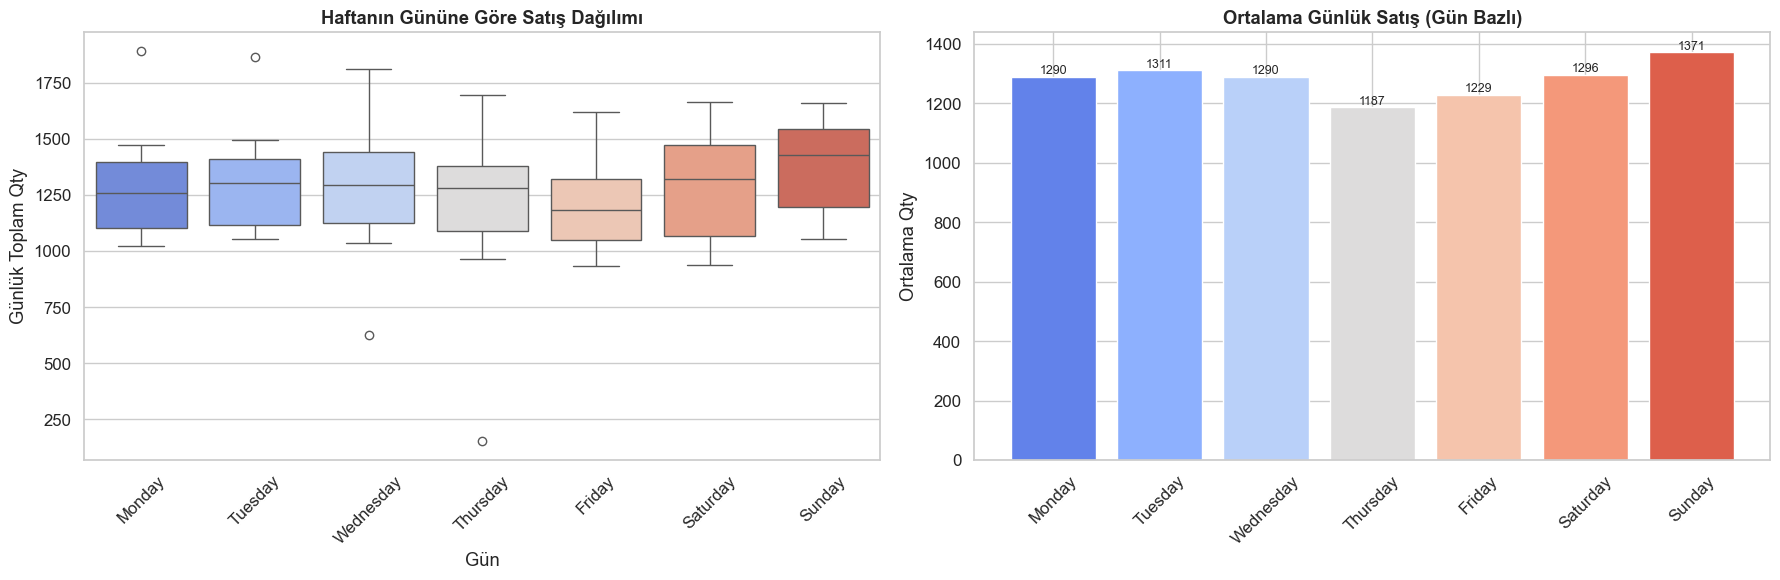

In [23]:
# Haftanın günü analizi
df_temp['DayOfWeek'] = df_temp['Date'].dt.day_name()
day_order = ['Monday', 'Tuesday', 'Wednesday', 'Thursday', 'Friday', 'Saturday', 'Sunday']

daily_dow = df_temp.groupby([df_temp['Date'], 'DayOfWeek'])['Qty'].sum().reset_index()

fig, axes = plt.subplots(1, 2, figsize=(18, 6))

# Box plot
sns.boxplot(data=daily_dow, x='DayOfWeek', y='Qty', order=day_order, 
            palette='coolwarm', ax=axes[0])
axes[0].set_title('Haftanın Gününe Göre Satış Dağılımı', fontweight='bold')
axes[0].set_xlabel('Gün')
axes[0].set_ylabel('Günlük Toplam Qty')
axes[0].tick_params(axis='x', rotation=45)

# Ortalama bar chart
dow_mean = daily_dow.groupby('DayOfWeek')['Qty'].mean().reindex(day_order)
axes[1].bar(dow_mean.index, dow_mean.values, color=sns.color_palette('coolwarm', 7))
axes[1].set_title('Ortalama Günlük Satış (Gün Bazlı)', fontweight='bold')
axes[1].set_ylabel('Ortalama Qty')
axes[1].tick_params(axis='x', rotation=45)
for i, v in enumerate(dow_mean.values):
    axes[1].text(i, v + 10, f'{v:.0f}', ha='center', fontsize=9)

plt.tight_layout()
plt.show()

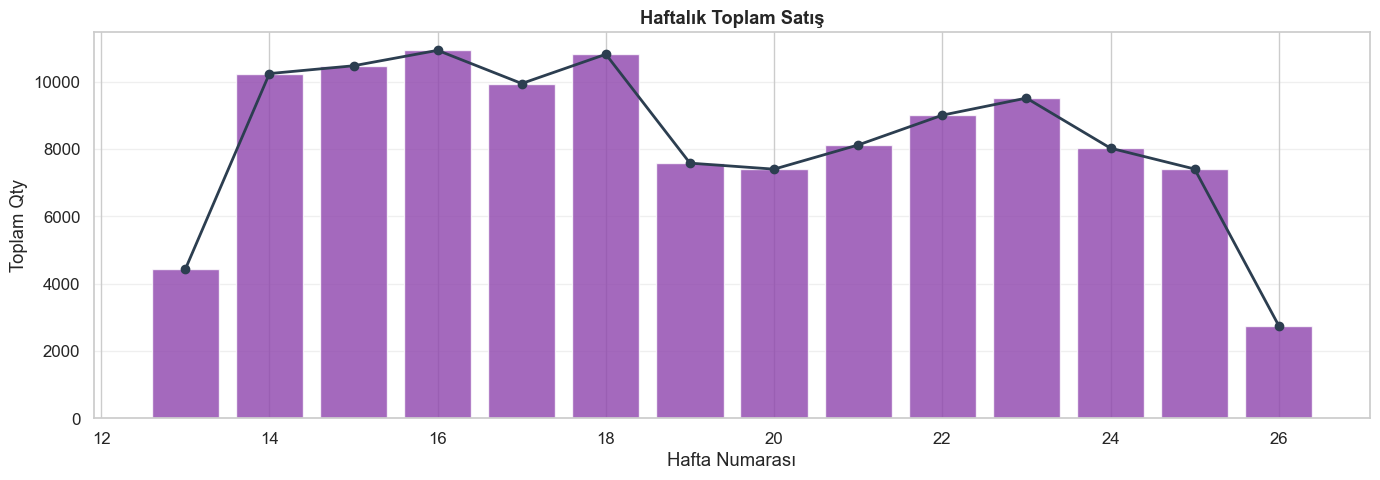

In [24]:
# Haftalık toplam trend
df_temp['Week'] = df_temp['Date'].dt.isocalendar().week.astype(int)
weekly_sales = df_temp.groupby('Week')['Qty'].sum()

fig, ax = plt.subplots(figsize=(14, 5))
ax.bar(weekly_sales.index, weekly_sales.values, color='#8e44ad', alpha=0.8)
ax.plot(weekly_sales.index, weekly_sales.values, color='#2c3e50', marker='o', linewidth=2)
ax.set_title('Haftalık Toplam Satış', fontweight='bold')
ax.set_xlabel('Hafta Numarası')
ax.set_ylabel('Toplam Qty')
ax.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.show()

---
## 8. Amount (Tutar) Analizi

In [25]:
# Amount eksik olanlar ile Qty ve Status ilişkisi
amount_null = df_raw['Amount'].isna()

print(f"Amount eksik: {amount_null.sum():,} satır")
print(df_raw.loc[amount_null, 'Status'].value_counts())
print(df_raw.loc[amount_null, 'Qty'].value_counts())

Amount eksik: 7,795 satır
Status
Cancelled                       7566
Shipped                          208
Shipped - Delivered to Buyer       8
Shipping                           8
Shipped - Returned to Seller       3
Pending                            2
Name: count, dtype: int64
Qty
0     7671
1      115
2        4
15       1
9        1
13       1
4        1
3        1
Name: count, dtype: int64


Amount eksik olanların Status dağılımı:

Amount eksik olanların Qty dağılımı:

Amount eksik olan kayıtlar neredeyse tamamen Cancelled siparişler ve Qty=0.
Bu satırlar zaten Status filtresinde düşürülecek.
Kalan (eğer varsa) eksikler kategori medyanıyla doldurulacak.


Amount eksik olan kayıtlar neredeyse tamamen Cancelled siparişler ve Qty=0.
Bu satırlar zaten Status filtresinde düşürülecek.
Kalan (eğer varsa) eksikler kategori medyanıyla doldurulacak.

> **İş Zekası Yorumu:**

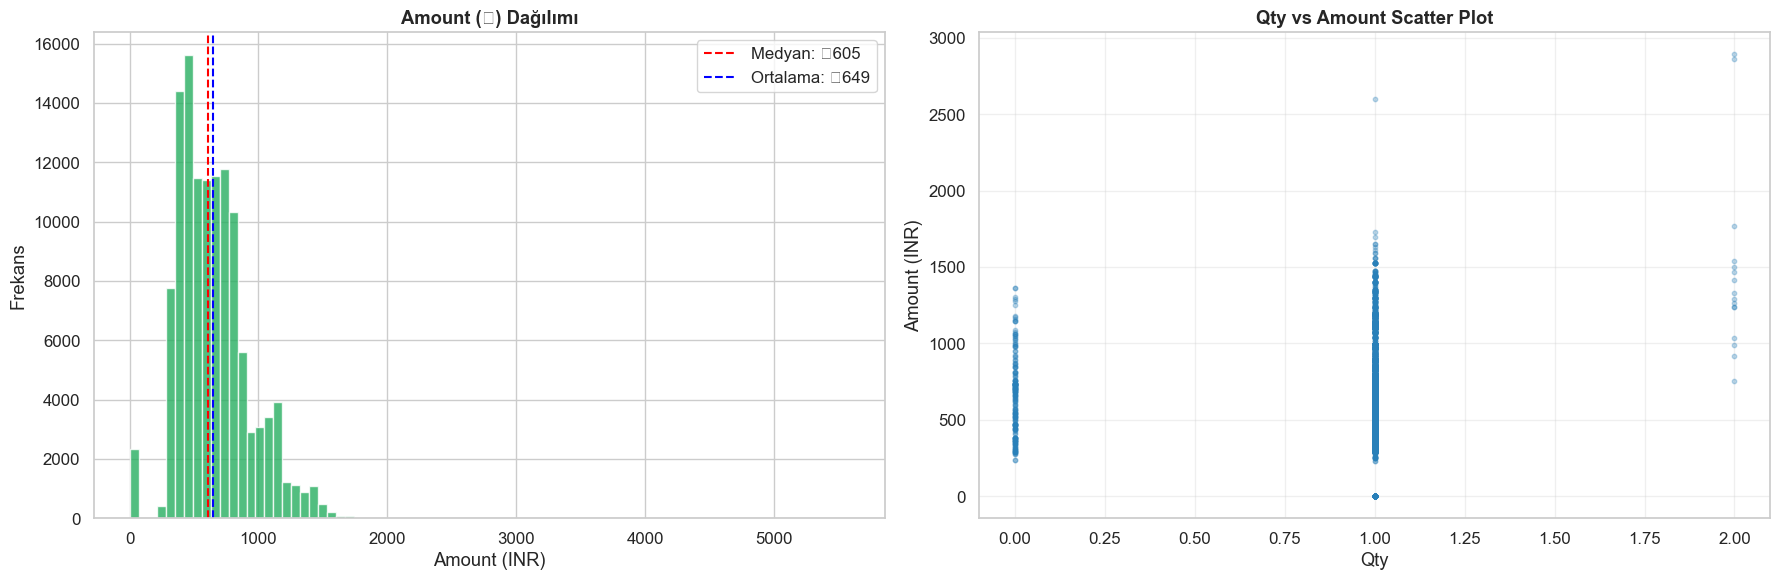

Amount istatistikleri:
  Min: ₹0.00
  Max: ₹5584.00
  Medyan: ₹605.00
  Ortalama: ₹648.56


In [26]:
# Amount dağılımı (boş olmayanlar)
amount_valid = df_raw['Amount'].dropna()

fig, axes = plt.subplots(1, 2, figsize=(18, 6))

# Histogram
axes[0].hist(amount_valid, bins=80, color='#27ae60', edgecolor='white', alpha=0.8)
axes[0].axvline(amount_valid.median(), color='red', linestyle='--', label=f'Medyan: ₹{amount_valid.median():.0f}')
axes[0].axvline(amount_valid.mean(), color='blue', linestyle='--', label=f'Ortalama: ₹{amount_valid.mean():.0f}')
axes[0].set_title('Amount (₹) Dağılımı', fontweight='bold')
axes[0].set_xlabel('Amount (INR)')
axes[0].set_ylabel('Frekans')
axes[0].legend()

# Amount vs Qty scatter
sample = df_raw.dropna(subset=['Amount']).sample(min(5000, len(df_raw)), random_state=42)
axes[1].scatter(sample['Qty'], sample['Amount'], alpha=0.3, s=10, color='#2980b9')
axes[1].set_title('Qty vs Amount Scatter Plot', fontweight='bold')
axes[1].set_xlabel('Qty')
axes[1].set_ylabel('Amount (INR)')
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

print(f'Amount istatistikleri:')
print(f'  Min: ₹{amount_valid.min():.2f}')
print(f'  Max: ₹{amount_valid.max():.2f}')
print(f'  Medyan: ₹{amount_valid.median():.2f}')
print(f'  Ortalama: ₹{amount_valid.mean():.2f}')

---
## 9. SKU Analizi

Toplam unique SKU: 7,195
Toplam unique Style: 1,377


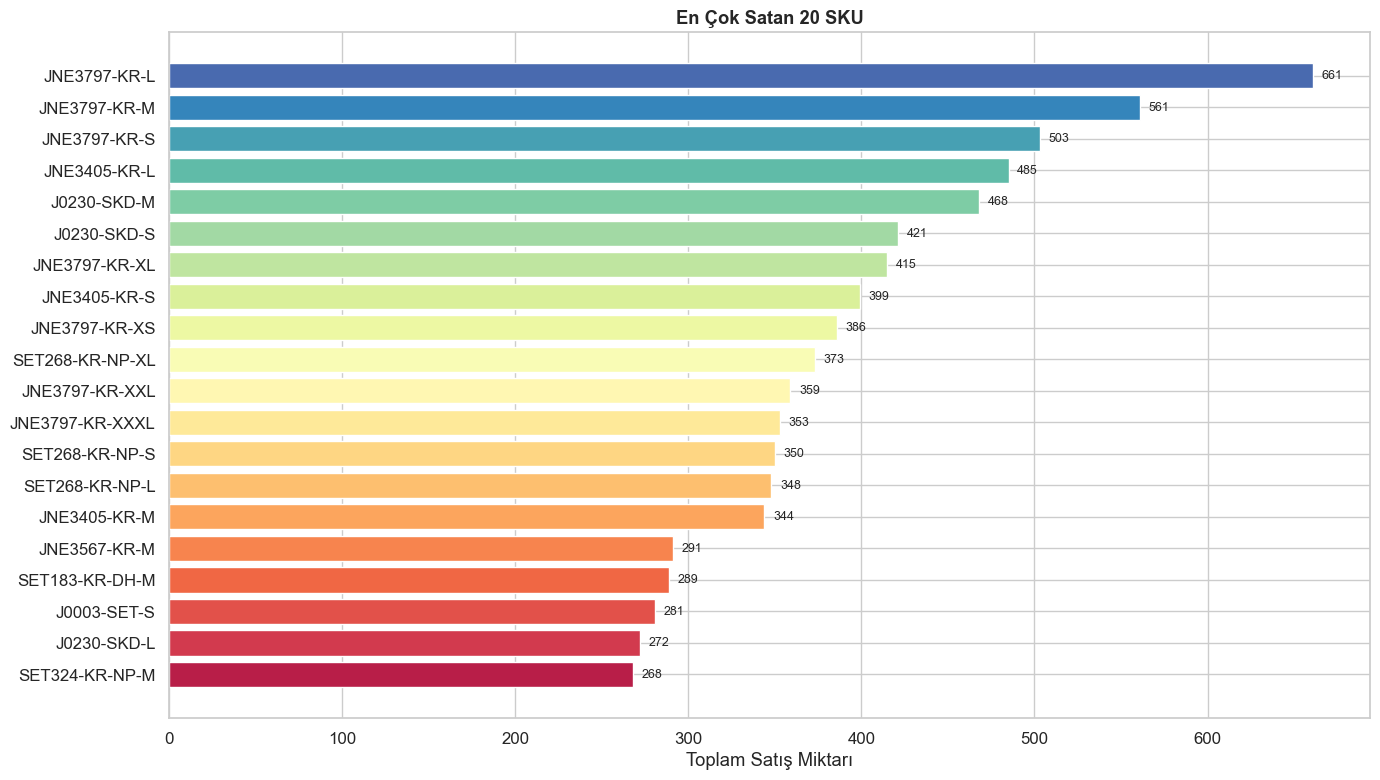

In [27]:
sku_qty = df_raw.groupby('SKU')['Qty'].sum().sort_values(ascending=False)

print(f'Toplam unique SKU: {df_raw["SKU"].nunique():,}')
print(f'Toplam unique Style: {df_raw["Style"].nunique():,}')

# Top 20 SKU
top20 = sku_qty.head(20)

fig, ax = plt.subplots(figsize=(14, 8))
bars = ax.barh(top20.index[::-1], top20.values[::-1], color=sns.color_palette('Spectral', 20))
ax.set_xlabel('Toplam Satış Miktarı')
ax.set_title('En Çok Satan 20 SKU', fontweight='bold')
for bar, val in zip(bars, top20.values[::-1]):
    ax.text(bar.get_width() + 5, bar.get_y() + bar.get_height()/2, 
            f'{val:,}', va='center', fontsize=9)
plt.tight_layout()
plt.show()

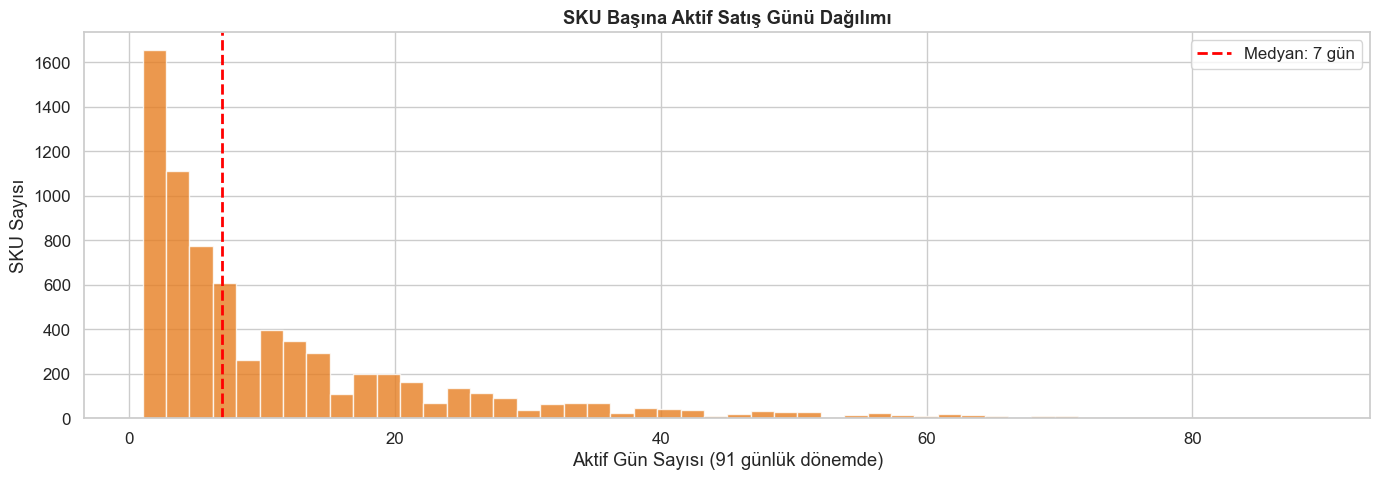

SKU aktif gün istatistikleri:
  Medyan: 7 gün
  Ortalama: 11.5 gün
  Min: 1 gün
  Max: 89 gün
  Sadece 1 gün aktif SKU sayısı: 938


In [28]:
# SKU başına aktif gün sayısı (kaç farklı günde satış yapılmış)
df_temp2 = df_raw.copy()
df_temp2['Date'] = pd.to_datetime(df_temp2['Date'], format='%m-%d-%y')
sku_active_days = df_temp2.groupby('SKU')['Date'].nunique()

fig, ax = plt.subplots(figsize=(14, 5))
ax.hist(sku_active_days, bins=50, color='#e67e22', edgecolor='white', alpha=0.8)
ax.axvline(sku_active_days.median(), color='red', linestyle='--', linewidth=2,
           label=f'Medyan: {sku_active_days.median():.0f} gün')
ax.set_title('SKU Başına Aktif Satış Günü Dağılımı', fontweight='bold')
ax.set_xlabel('Aktif Gün Sayısı (91 günlük dönemde)')
ax.set_ylabel('SKU Sayısı')
ax.legend()
plt.tight_layout()
plt.show()

print(f'SKU aktif gün istatistikleri:')
print(f'  Medyan: {sku_active_days.median():.0f} gün')
print(f'  Ortalama: {sku_active_days.mean():.1f} gün')
print(f'  Min: {sku_active_days.min()} gün')
print(f'  Max: {sku_active_days.max()} gün')
print(f'  Sadece 1 gün aktif SKU sayısı: {(sku_active_days == 1).sum()}')


Preprocessing\'de minimum aktif gün eşiği koyulabilir.

> **İş Zekası Yorumu:** Çok kısa ömürlü (<7 gün) SKU\'lar tahmin modeli için yeterli veri noktasına sahip değil.

---
## 10. Coğrafi Analiz

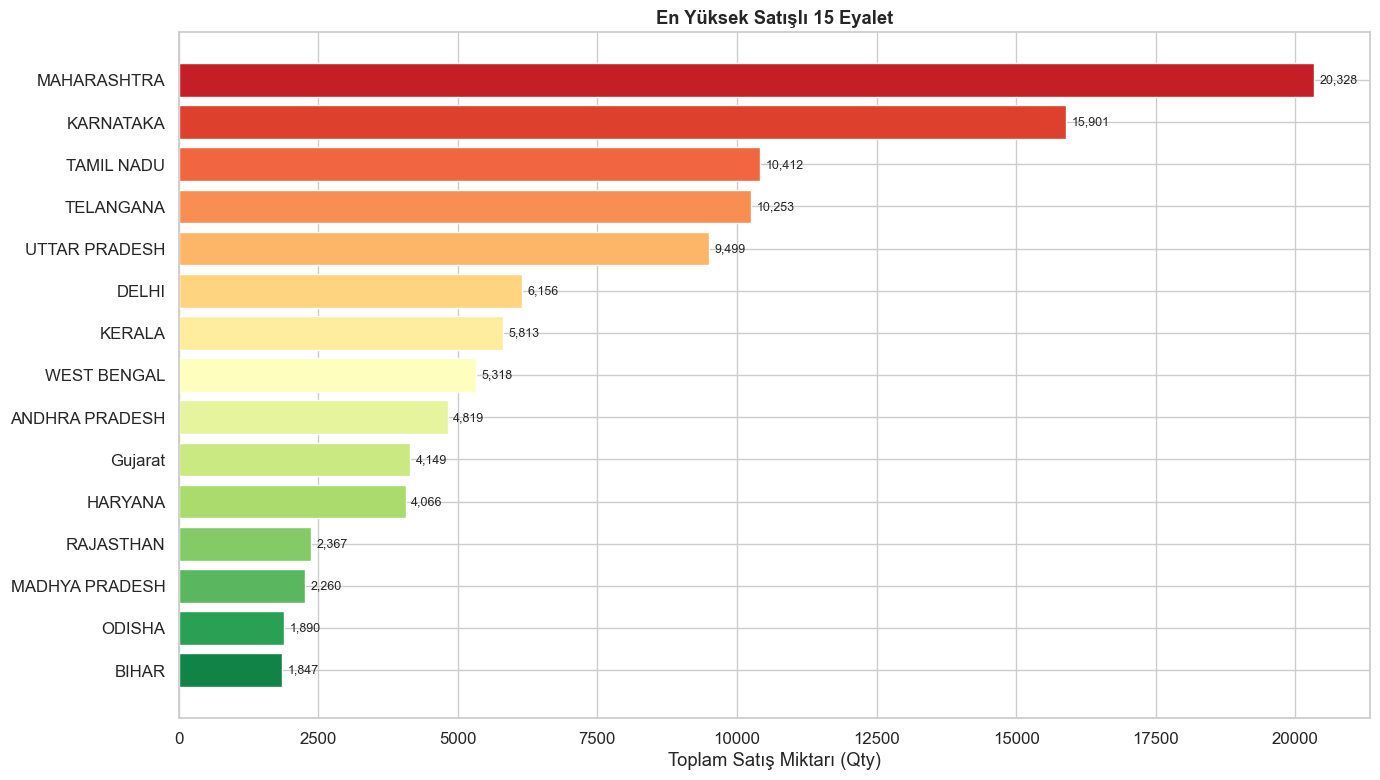

In [29]:
state_sales = df_raw.groupby('ship-state')['Qty'].sum().sort_values(ascending=False)

fig, ax = plt.subplots(figsize=(14, 8))
top_states = state_sales.head(15)
ax.barh(top_states.index[::-1], top_states.values[::-1], 
        color=sns.color_palette('RdYlGn', len(top_states))[::-1])
ax.set_xlabel('Toplam Satış Miktarı (Qty)')
ax.set_title('En Yüksek Satışlı 15 Eyalet', fontweight='bold')
for i, val in enumerate(top_states.values[::-1]):
    ax.text(val + 100, i, f'{val:,}', va='center', fontsize=9)
plt.tight_layout()
plt.show()

---
## 11. Korelasyon Analizi

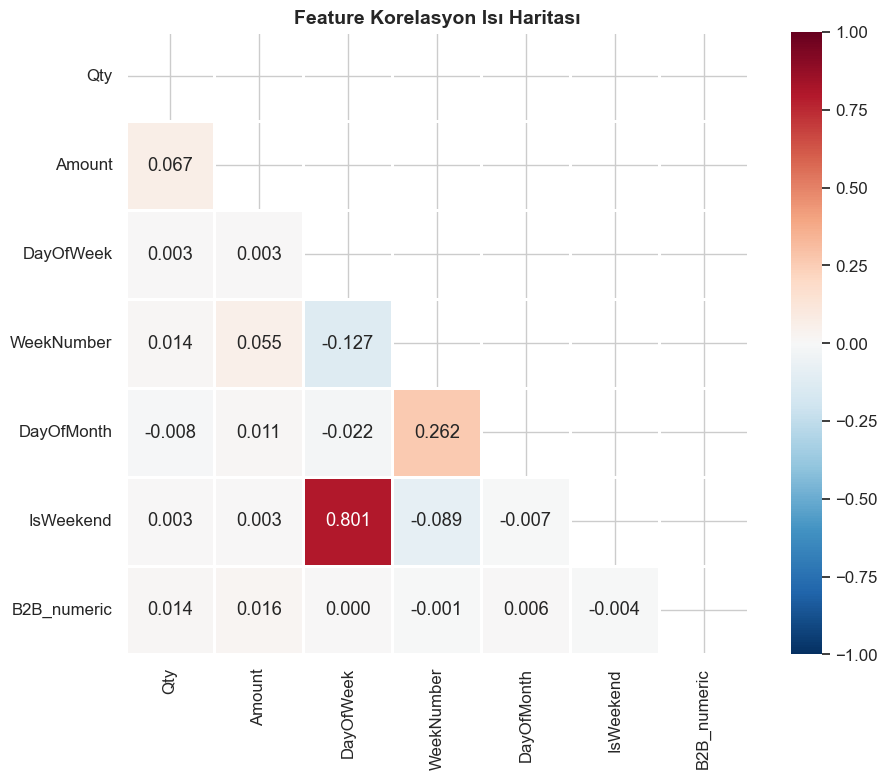

In [30]:
# Sayısal sütunlar arası korelasyon
numeric_cols = df_raw[['Qty', 'Amount']].dropna()

# Daha zengin korelasyon için tarih bazlı feature'lar ekleyelim
df_corr = df_raw.copy()
df_corr['Date'] = pd.to_datetime(df_corr['Date'], format='%m-%d-%y')
df_corr['DayOfWeek'] = df_corr['Date'].dt.dayofweek
df_corr['WeekNumber'] = df_corr['Date'].dt.isocalendar().week.astype(int)
df_corr['DayOfMonth'] = df_corr['Date'].dt.day
df_corr['IsWeekend'] = (df_corr['DayOfWeek'] >= 5).astype(int)
df_corr['B2B_numeric'] = df_corr['B2B'].map({True: 1, False: 0, 'True': 1, 'False': 0}).fillna(0)

corr_features = ['Qty', 'Amount', 'DayOfWeek', 'WeekNumber', 'DayOfMonth', 'IsWeekend', 'B2B_numeric']
corr_matrix = df_corr[corr_features].dropna().corr()

fig, ax = plt.subplots(figsize=(10, 8))
mask = np.triu(np.ones_like(corr_matrix, dtype=bool))  # Üst üçgen maskeleme
sns.heatmap(corr_matrix, mask=mask, annot=True, fmt='.3f', cmap='RdBu_r', 
            center=0, linewidths=1, ax=ax, vmin=-1, vmax=1,
            square=True)
ax.set_title('Feature Korelasyon Isı Haritası', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()



- Qty ve Amount arasında pozitif korelasyon beklenir
- DayOfWeek/IsWeekend ile satış arasında haftalık döngü ipucu olabilir
- WeekNumber ile trend gösterir (artan/azalan)

> **İş Zekası Yorumu:**

---
## 12. B2B Analizi

B2B
False    128104
True        871
Name: count, dtype: int64


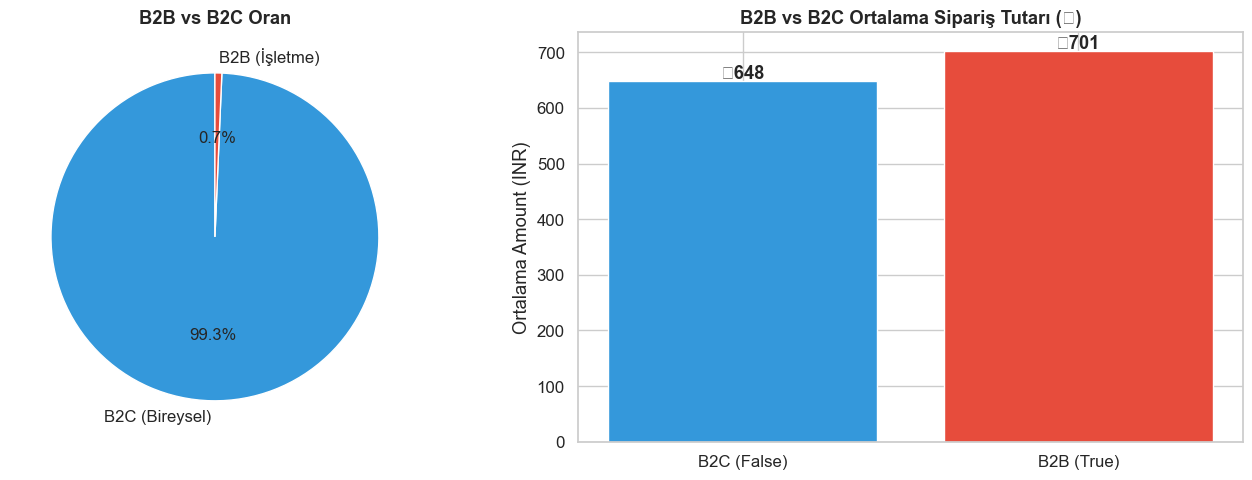

In [31]:
b2b_dist = df_raw['B2B'].value_counts()
print(b2b_dist)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].pie(b2b_dist.values, labels=['B2C (Bireysel)', 'B2B (İşletme)'], 
            colors=['#3498db', '#e74c3c'], autopct='%1.1f%%', startangle=90,
            textprops={'fontsize': 12})
axes[0].set_title('B2B vs B2C Oran', fontweight='bold')

# B2B vs B2C ortalama Amount
b2b_amount = df_raw.groupby('B2B')['Amount'].mean().dropna()
axes[1].bar(['B2C (False)', 'B2B (True)'], b2b_amount.values, color=['#3498db', '#e74c3c'])
axes[1].set_title('B2B vs B2C Ortalama Sipariş Tutarı (₹)', fontweight='bold')
axes[1].set_ylabel('Ortalama Amount (INR)')
for i, v in enumerate(b2b_amount.values):
    axes[1].text(i, v + 5, f'₹{v:.0f}', ha='center', fontweight='bold')

plt.tight_layout()
plt.show()

B2B dağılımı:

---
## 13. Size (Beden) Analizi

Unique beden sayısı: 11
Size
M       22711
L       22132
XL      20876
XXL     18096
S       17090
3XL     14816
XS      11161
6XL       738
5XL       550
4XL       427
Free      378
Name: count, dtype: int64


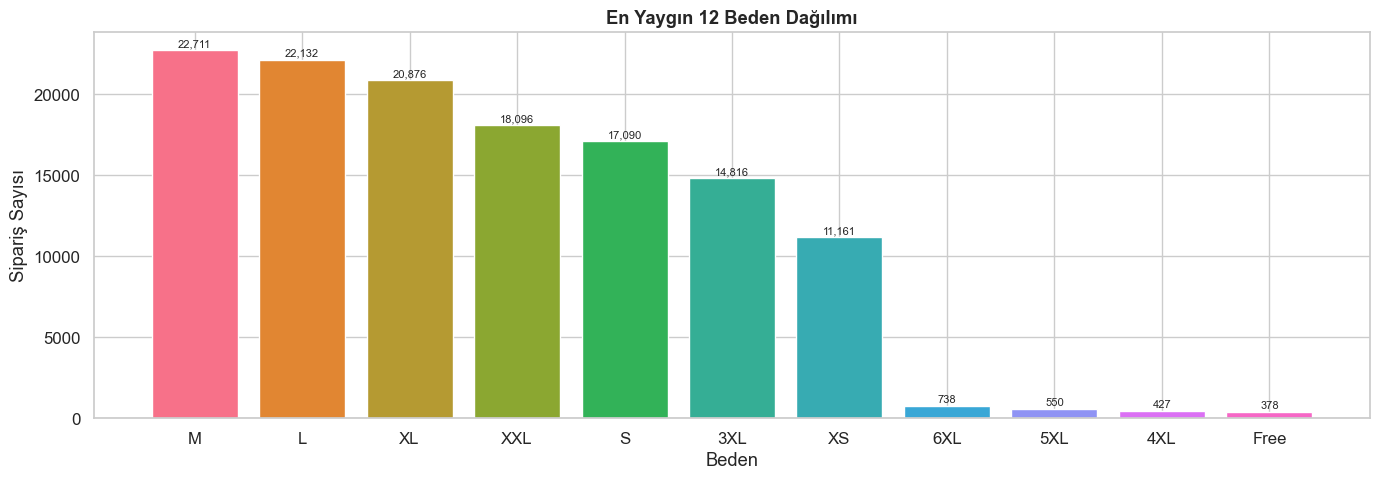

In [32]:
size_counts = df_raw['Size'].value_counts()
print(f'Unique beden sayısı: {len(size_counts)}')
print(size_counts.head(15))

fig, ax = plt.subplots(figsize=(14, 5))
top_sizes = size_counts.head(12)
ax.bar(top_sizes.index, top_sizes.values, color=sns.color_palette('husl', len(top_sizes)))
ax.set_title('En Yaygın 12 Beden Dağılımı', fontweight='bold')
ax.set_xlabel('Beden')
ax.set_ylabel('Sipariş Sayısı')
for i, v in enumerate(top_sizes.values):
    ax.text(i, v + 200, f'{v:,}', ha='center', fontsize=8)
plt.tight_layout()
plt.show()



Beden dağılımı (Top 15):

> **Analiz Kararı:** TUT  — Beden bilgisi SKU düzeyinde tahmin yapmak için feature olarak kullanılabilir.

---
---
# PREPROCESSING PIPELINE

Yukarıdaki EDA bulgularına dayanarak temiz veri oluşturuyoruz.

## Özet Kararlar

| Adım | Aksiyon | Gerekçe |
|---|---|---|
| 1 | `index`, `Unnamed: 22` düşür | Artık sütun, bilgi değeri yok |
| 2 | `currency` düşür | Sıfır varyans (tümü INR) |
| 3 | `Sales Channel ` düşür | Sıfır varyans (tümü Amazon.in) |
| 4 | `promotion-ids` düşür | %38 boş, tahminle ilgisiz |
| 5 | `fulfilled-by` düşür | %69.6 boş, Fulfilment ile örtüşüyor |
| 6 | `Courier Status` düşür | Status ile redundant |
| 7 | `ASIN` düşür | Amazon iç ID, SKU yeterli |
| 8 | `ship-service-level` düşür | Kargo hızı, talep tahminiyle ilgisiz |
| 9 | `ship-country` düşür | Tümü IN |
| 10 | İptal + iade statülerini filtrele | Gerçek talep sinyali değil |
| 11 | Date → datetime | Zaman serisi feature'ları |
| 12 | Amount eksik → kategori medyanı | Sağlam imputation |
| 13 | ship bilgileri (33 satır) → mod | Çok az eksik, mod güvenilir |
| 14 | B2B → binary int | Model uyumu |
| 15 | Yeni feature'lar türet | day_of_week, week_number, is_weekend, month |

In [33]:
# ============================
# PREPROCESSING PIPELINE
# ============================

df = df_raw.copy()  # Orijinal DataFrame'e dokunmuyoruz
print(f'Başlangıç: {df.shape[0]:,} satır × {df.shape[1]} sütun')
print('=' * 60)

Başlangıç: 128,975 satır × 24 sütun


In [34]:
# ADIM 1: Gereksiz sütunları düşür
drop_cols = [
    'index',              # Artık satır numarası
    'Unnamed: 22',        # Anlamsız artık sütun
    'currency',           # Sıfır varyans (tümü INR)
    'Sales Channel ',     # Sıfır varyans (tümü Amazon.in)
    'promotion-ids',      # %38 boş, tahminle ilgisiz
    'fulfilled-by',       # %69.6 boş, Fulfilment ile redundant
    'Courier Status',     # Status ile redundant
    'ASIN',               # Amazon iç ID, SKU yeterli
    'ship-service-level', # Kargo hızı, tahminle ilgisiz
    'ship-country',       # Tümü IN — sıfır varyans
]

df = df.drop(columns=drop_cols, errors='ignore')
print(f'Adım 1 — {len(drop_cols)} sütun düşürüldü: {df.shape[1]} sütun kaldı')
print(f'  Düşürülen: {drop_cols}')

Adım 1 — 10 sütun düşürüldü: 14 sütun kaldı
  Düşürülen: ['index', 'Unnamed: 22', 'currency', 'Sales Channel ', 'promotion-ids', 'fulfilled-by', 'Courier Status', 'ASIN', 'ship-service-level', 'ship-country']


In [35]:
# ADIM 2: Tarih parse et
df['Date'] = pd.to_datetime(df['Date'], format='%m-%d-%y')
print(f'Adım 2 — Date sütunu datetime\'a çevrildi')
print(f'  Aralık: {df["Date"].min().date()} → {df["Date"].max().date()}')

Adım 2 — Date sütunu datetime'a çevrildi
  Aralık: 2022-03-31 → 2022-06-29


In [36]:
# ADIM 3: Status filtresi — sadece gerçek satışları tut
valid_statuses = [
    'Shipped',
    'Shipped - Delivered to Buyer',
    'Shipped - Out for Delivery',
    'Shipped - Picked Up',
    'Pending',
    'Pending - Waiting for Pick Up',
    'Shipping',
]

before = len(df)
df = df[df['Status'].isin(valid_statuses)]
after = len(df)
print(f'Adım 3 — Status filtresi: {before:,} → {after:,} ({before - after:,} satır düşürüldü)')
print(f'  Kalan statüler: {df["Status"].unique()}')

Adım 3 — Status filtresi: 128,975 → 108,528 (20,447 satır düşürüldü)
  Kalan statüler: ['Shipped - Delivered to Buyer' 'Shipped' 'Shipped - Out for Delivery'
 'Shipped - Picked Up' 'Pending' 'Pending - Waiting for Pick Up'
 'Shipping']


In [37]:
# ADIM 4: Amount eksik değerleri doldur
amount_null_count = df['Amount'].isna().sum()
print(f'Adım 4 — Amount eksik: {amount_null_count} satır')

if amount_null_count > 0:
    # Qty == 0 olan satırlar için Amount = 0.0
    mask_qty0 = (df['Amount'].isna()) & (df['Qty'] == 0)
    df.loc[mask_qty0, 'Amount'] = 0.0
    print(f'  Qty=0 olanlar → Amount=0: {mask_qty0.sum()} satır')
    
    # Kalan eksikler → kategoriye göre medyan
    remaining_null = df['Amount'].isna().sum()
    if remaining_null > 0:
        category_medians = df.groupby('Category')['Amount'].transform('median')
        df['Amount'] = df['Amount'].fillna(category_medians)
        # Hâlâ kalan varsa genel medyan
        df['Amount'] = df['Amount'].fillna(df['Amount'].median())
        print(f'  Kategori medyanı ile doldurulan: {remaining_null} satır')
    
    print(f'  Amount eksik kalan: {df["Amount"].isna().sum()}')
else:
    pass


Adım 4 — Amount eksik: 226 satır
  Qty=0 olanlar → Amount=0: 103 satır
  Kategori medyanı ile doldurulan: 123 satır
  Amount eksik kalan: 0


Eksik değer yok — işlem gerekmedi.

In [38]:
# ADIM 5: ship-city / ship-state / ship-postal-code eksiklerini doldur
for col in ['ship-city', 'ship-state', 'ship-postal-code']:
    null_count = df[col].isna().sum()
    if null_count > 0:
        mode_val = df[col].mode()[0]
        df[col] = df[col].fillna(mode_val)
        print(f'  {col}: {null_count} eksik → mod ({mode_val}) ile dolduruldu')
    else:
        print(f'  {col}: Eksik değer yok')

  ship-city: 23 eksik → mod (BENGALURU) ile dolduruldu
  ship-state: 23 eksik → mod (MAHARASHTRA) ile dolduruldu
  ship-postal-code: 23 eksik → mod (201301.0) ile dolduruldu


In [39]:
# ADIM 6: B2B → binary integer
df['B2B'] = df['B2B'].map({'True': 1, 'False': 0, True: 1, False: 0}).fillna(0).astype(int)
print(f'Adım 6 — B2B sütunu integer\'a çevrildi')
print(f'  Dağılım: {df["B2B"].value_counts().to_dict()}')

Adım 6 — B2B sütunu integer'a çevrildi
  Dağılım: {0: 107739, 1: 789}


In [40]:
# ADIM 7: Yeni feature'lar türet
df['day_of_week'] = df['Date'].dt.dayofweek          # 0=Mon, 6=Sun
df['week_number'] = df['Date'].dt.isocalendar().week.astype(int)
df['month'] = df['Date'].dt.month
df['is_weekend'] = (df['day_of_week'] >= 5).astype(int)
df['day_of_month'] = df['Date'].dt.day

print('  day_of_week, week_number, month, is_weekend, day_of_month')
print(f'  Mevcut sütun sayısı: {df.shape[1]}')

  day_of_week, week_number, month, is_weekend, day_of_month
  Mevcut sütun sayısı: 19


Adım 7 — Yeni feature\'lar türetildi:

In [41]:
# ADIM 8: Sütun isimlerini standartlaştır (snake_case)
df = df.rename(columns={
    'Order ID': 'order_id',
    'Date': 'date',
    'Status': 'status',
    'Fulfilment': 'fulfilment',
    'Style': 'style',
    'SKU': 'sku',
    'Category': 'category',
    'Size': 'size',
    'Qty': 'qty',
    'Amount': 'amount',
    'ship-city': 'ship_city',
    'ship-state': 'ship_state',
    'ship-postal-code': 'ship_postal_code',
    'B2B': 'b2b',
})

print(f'  Sütunlar: {list(df.columns)}')

  Sütunlar: ['order_id', 'date', 'status', 'fulfilment', 'style', 'sku', 'category', 'size', 'qty', 'amount', 'ship_city', 'ship_state', 'ship_postal_code', 'b2b', 'day_of_week', 'week_number', 'month', 'is_weekend', 'day_of_month']


Adım 8 — Sütun isimleri standartlaştırıldı (snake_case)

---
## 14. Temizlenmiş Veri Profili

In [42]:
print('=' * 60)
print('=' * 60)
print(f'Boyut: {df.shape[0]:,} satır × {df.shape[1]} sütun')
print(f'Orijinalden düşen satır: {len(df_raw) - len(df):,} ({(1 - len(df)/len(df_raw))*100:.1f}%)')
print(f'Orijinalden düşen sütun: {df_raw.shape[1] - df.shape[1]}')
remaining_null = df.isnull().sum()
if remaining_null.sum() == 0:
    pass
else:
    print(remaining_null[remaining_null > 0])
df.info()

Boyut: 108,528 satır × 19 sütun
Orijinalden düşen satır: 20,447 (15.9%)
Orijinalden düşen sütun: 5
<class 'pandas.core.frame.DataFrame'>
Index: 108528 entries, 1 to 128974
Data columns (total 19 columns):
 #   Column            Non-Null Count   Dtype         
---  ------            --------------   -----         
 0   order_id          108528 non-null  object        
 1   date              108528 non-null  datetime64[ns]
 2   status            108528 non-null  object        
 3   fulfilment        108528 non-null  object        
 4   style             108528 non-null  object        
 5   sku               108528 non-null  object        
 6   category          108528 non-null  object        
 7   size              108528 non-null  object        
 8   qty               108528 non-null  int64         
 9   amount            108528 non-null  float64       
 10  ship_city         108528 non-null  object        
 11  ship_state        108528 non-null  object        
 12  ship_postal_code  10

TEMİZLENMİŞ VERİ PROFİLİ

Eksik veri kaldı mı?
✅ Hayır — tüm sütunlar tamamen dolu!

In [43]:
df.describe(include='all').T

,count,unique,top,freq,mean,min,25%,50%,75%,max,std
order_id,108528,101196,403-4984515-8861958,12,NaN,NaN,NaN,NaN,NaN,NaN,NaN
date,108528,NaN,NaN,NaN,2022-05-12 15:18:56.842105344,2022-03-31 00:00:00,2022-04-20 00:00:00,2022-05-10 00:00:00,2022-06-05 00:00:00,2022-06-29 00:00:00,NaN
status,108528,7,Shipped,77804,NaN,NaN,NaN,NaN,NaN,NaN,NaN
fulfilment,108528,2,Amazon,78227,NaN,NaN,NaN,NaN,NaN,NaN,NaN
style,108528,1369,JNE3797,3458,NaN,NaN,NaN,NaN,NaN,NaN,NaN
sku,108528,7107,JNE3797-KR-L,622,NaN,NaN,NaN,NaN,NaN,NaN,NaN
category,108528,9,Set,42100,NaN,NaN,NaN,NaN,NaN,NaN,NaN
size,108528,11,M,18925,NaN,NaN,NaN,NaN,NaN,NaN,NaN
qty,108528.0,NaN,NaN,NaN,1.003013,0.0,1.0,1.0,1.0,15.0,0.099202
amount,108528.0,NaN,NaN,NaN,648.33009,0.0,449.0,603.0,788.0,5584.0,283.444606


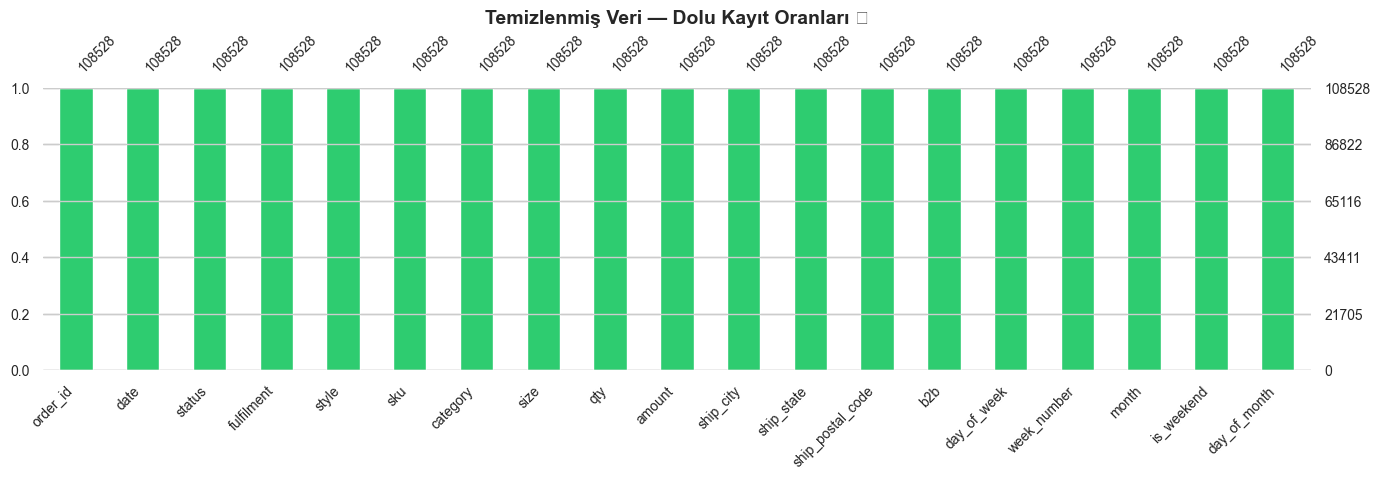

In [44]:
# Temiz veri üzerinde son bir eksik değer kontrolü (missingno)
fig, ax = plt.subplots(figsize=(14, 5))
msno.bar(df, ax=ax, fontsize=10, color=(0.18, 0.80, 0.44))
ax.set_title('Temizlenmiş Veri — Dolu Kayıt Oranları ✅', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

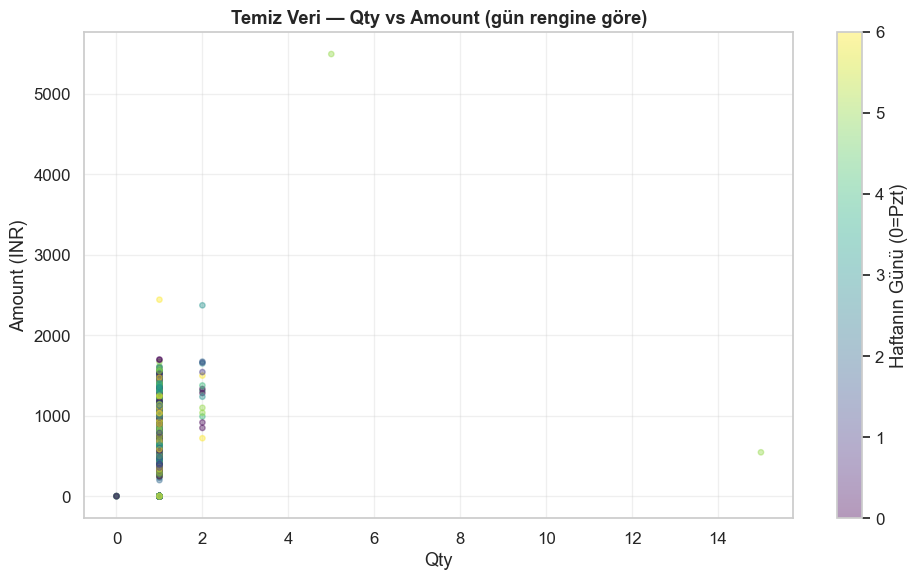

In [45]:
# Son scatter plot: temiz veride Qty vs Amount
fig, ax = plt.subplots(figsize=(10, 6))
sample_clean = df.sample(min(5000, len(df)), random_state=42)
scatter = ax.scatter(sample_clean['qty'], sample_clean['amount'], 
                     c=sample_clean['day_of_week'], cmap='viridis',
                     alpha=0.4, s=15)
ax.set_title('Temiz Veri — Qty vs Amount (gün rengine göre)', fontweight='bold')
ax.set_xlabel('Qty')
ax.set_ylabel('Amount (INR)')
plt.colorbar(scatter, label='Haftanın Günü (0=Pzt)')
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

---
## 15. Temizlenmiş Veriyi Kaydet

> ⚠️ Orijinal `Amazon Sale Report.csv` dosyasına **dokunulmamıştır**.

In [46]:
OUTPUT_PATH = '../database/cleaned_sales.csv'

df.to_csv(OUTPUT_PATH, index=False)
print(f'✅ Temizlenmiş veri kaydedildi: {OUTPUT_PATH}')
print(f'   Boyut: {df.shape[0]:,} satır × {df.shape[1]} sütun')


✅ Temizlenmiş veri kaydedildi: ../database/cleaned_sales.csv
   Boyut: 108,528 satır × 19 sütun


In [47]:
# Doğrulama — kaydedilen dosyayı geri oku
df_check = pd.read_csv(OUTPUT_PATH)
assert df_check.shape == df.shape, 'HATA: Boyut uyumsuz!'
assert df_check.isnull().sum().sum() == df.isnull().sum().sum(), 'HATA: Eksik değer uyumsuz!'
print(f'✅ Doğrulama başarılı: {df_check.shape[0]:,} × {df_check.shape[1]} — orijinal ile eşleşiyor')

✅ Doğrulama başarılı: 108,528 × 19 — orijinal ile eşleşiyor


---
## EDA Özet

### Düşürülen 10 Sütun
| # | Sütun | Gerekçe |
|---|---|---|
| 1 | `index` | Artık satır numarası |
| 2 | `Unnamed: 22` | Anlamsız, %38 boş |
| 3 | `currency` | Sıfır varyans (tümü INR) |
| 4 | `Sales Channel` | Sıfır varyans (tümü Amazon.in) |
| 5 | `promotion-ids` | %38 boş, karmaşık string, tahminle ilgisiz |
| 6 | `fulfilled-by` | %69.6 boş, Fulfilment ile örtüşüyor |
| 7 | `Courier Status` | Status ile redundant |
| 8 | `ASIN` | Amazon iç ID |
| 9 | `ship-service-level` | Kargo türü, tahminle ilgisiz |
| 10 | `ship-country` | Sıfır varyans (tümü IN) |

### Filtrelenen Satırlar
- İptal, iade, kayıp, hasar statüleri filtrelendi (~20K satır)

### Eksik Değer Doldurma
- `Amount`: Qty=0 ise 0, diğerleri kategori medyanı
- `ship-city/state/postal-code`: mod ile doldurma (33 satır)

### Türetilen Feature'lar
- `day_of_week`, `week_number`, `month`, `is_weekend`, `day_of_month`

### Çıktı
- `cleaned_sales.csv` → SQLite dönüşümü için hazır